<a href="https://colab.research.google.com/github/Shedjohn/mnist-digit-classifier/blob/main/MNIST_classifier_ANN_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [ ]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


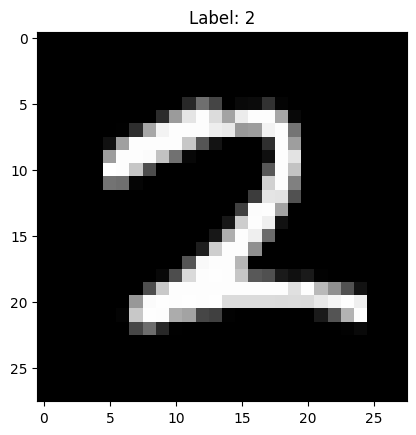

In [ ]:
import matplotlib.pyplot as plt

image = images[0].squeeze()
label = labels[0]

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = self.flatten(x)

        logits = self.linear_relu_stack(x)

        return logits

In [ ]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

model = model.to(device)

cuda


In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.01
)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = loss_fn(outputs, labels)

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.2488
Epoch [2/5], Loss: 0.1407
Epoch [3/5], Loss: 0.1208
Epoch [4/5], Loss: 0.1110
Epoch [5/5], Loss: 0.0996


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.47%


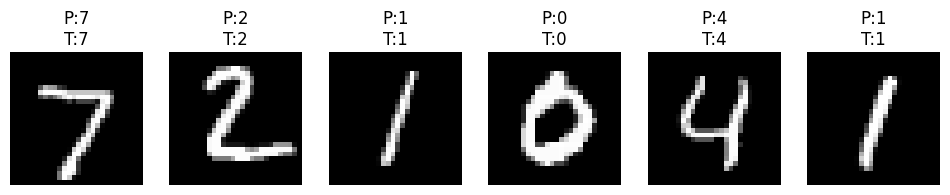

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    outputs = model(images)

    _, predictions = torch.max(outputs, 1)

# Move to CPU for plotting
images = images.cpu()
predictions = predictions.cpu()
labels = labels.cpu()

# Show first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):

    axes[i].imshow(images[i].squeeze(), cmap='gray')

    axes[i].set_title(
        f"P:{predictions[i]}\nT:{labels[i]}"
    )

    axes[i].axis("off")

plt.show()